<a href="https://colab.research.google.com/github/shifanamattil/churn-prediction/blob/main/svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# 1. Import Libraries
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

In [ ]:
# =========================================================
# 2. Load Datasets
# =========================================================
customer_df = pd.read_csv("customer_data (1).csv")
internet_df = pd.read_csv("internet_data (1).csv")
churn_df = pd.read_csv("churn_data (1).csv")


# =========================================================
# 3. Merge Datasets
# =========================================================
df = customer_df.merge(internet_df, on="customerID", how="inner")
df = df.merge(churn_df, on="customerID", how="inner")

df.drop(columns=["customerID"], inplace=True)



In [ ]:
# =========================================================
# 4. Target Variable
# =========================================================
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


# =========================================================
# 5. Handle TotalCharges Issue
# =========================================================
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)


In [ ]:
# =========================================================
# 6. Encode Categorical Variables
# =========================================================
df = pd.get_dummies(df, drop_first=True)




In [ ]:
# =========================================================
# 7. Split Features and Target
# =========================================================
X = df.drop("Churn", axis=1)
y = df["Churn"]

feature_names = X.columns

In [ ]:
# =========================================================
# 8. Train Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
# =========================================================
# 9. Feature Scaling (MANDATORY for PCA & SVM)
# =========================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# =========================================================
# 10. Handle Class Imbalance (SMOTE)
# =========================================================
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)



In [ ]:

# =========================================================
# 11. Dimensionality Reduction (PCA)
# =========================================================
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_smote)
X_test_pca = pca.transform(X_test_scaled)

print("\nNumber of PCA Components selected:", pca.n_components_)




Number of PCA Components selected: 17


In [ ]:
# =========================================================
# 12. SVM Model
# =========================================================
svm_model = SVC(probability=True)


In [ ]:

# =========================================================
# 13. Hyperparameter Grid
# =========================================================
param_grid = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"]
}


In [ ]:
# =========================================================
# 14. GridSearchCV
# =========================================================
grid = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train_pca, y_train_smote)

best_model = grid.best_estimator_



In [ ]:
# =========================================================
# 15. Predictions
# =========================================================
y_pred = best_model.predict(X_test_pca)
y_prob = best_model.predict_proba(X_test_pca)[:,1]


In [ ]:

# =========================================================
# 16. Evaluation Metrics
# =========================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n================ MODEL PERFORMANCE ================\n")

print("Best Parameters Found:")
print(grid.best_params_)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")



================ MODEL PERFORMANCE ================

Best Parameters Found:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Accuracy:  0.7495
Precision: 0.5237
Recall:    0.6203
F1 Score:  0.5679
MCC:       0.3961
ROC-AUC:   0.7966


In [ ]:
# =========================================================
# 17. Sensitivity & Specificity
# =========================================================
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\n================ ADDITIONAL METRICS ================\n")

print(f"Sensitivity (TPR): {sensitivity*100:.2f}%")
print(f"Specificity (TNR): {specificity*100:.2f}%")



================ ADDITIONAL METRICS ================

Sensitivity (TPR): 62.03%
Specificity (TNR): 79.61%

================ ADDITIONAL METRICS ================

Sensitivity (TPR): 62.03%
Specificity (TNR): 79.61%


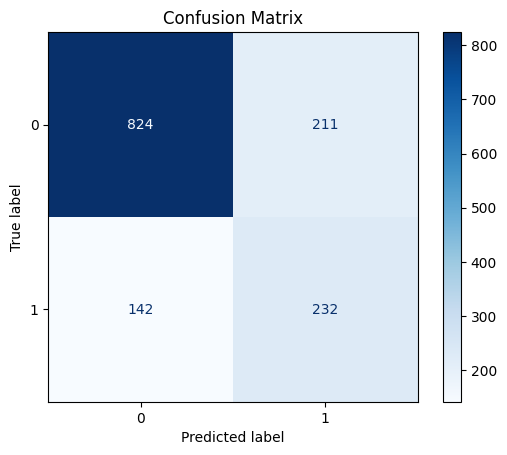

In [ ]:
# =========================================================
# 18. Confusion Matrix Visualization
# =========================================================
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()


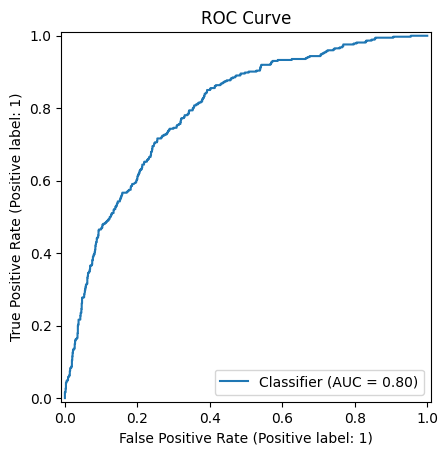

In [ ]:
# =========================================================
# 19. ROC Curve
# =========================================================
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()


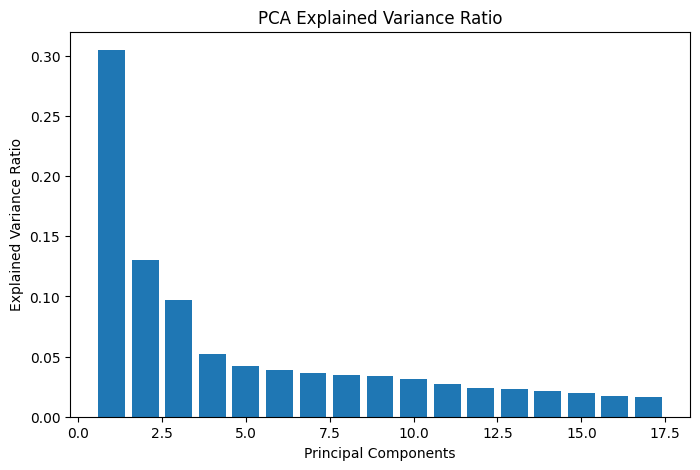

In [ ]:
# =========================================================
# 20. PCA Explained Variance Plot
# =========================================================
plt.figure(figsize=(8,5))

plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance Ratio")

plt.show()